In [2]:
import torch
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

from utils.dataMaker import DataHandler
import utils.plotter as plotter
import datasets.dataLoader as dataLoader
import config

### Data Paths

In [2]:
data_dir = '/workspace/data/'

# Simulated data
train_data = data_dir + '/grid_data_atten_big_train.h5'
val_data = data_dir + '/grid_data_atten_big_val.h5'
test_data = data_dir + '/grid_data_atten_big_test.h5'
mat_data = data_dir + '/grid_data_atten.mat'
mat_noise = data_dir + '/noise_only_data_atten.mat'

# Experimental data
warped_dir = data_dir + '/warped_calls_D72_cb1461'
collected_data = data_dir + '/call_collection'
exp_data = data_dir + '/wav_calls.h5'

max_range = config.max_range

## Simulated Data

### Generate Spectrogams

Here we generate spectrograms from the .mat files which contain the results of the [KRAKEN](https://oalib-acoustics.org/models-and-software/normal-modes/) simulation.

In [29]:
# Load simulated data into data object
handler = DataHandler(path=config.mat_data, noise_only_path=config.mat_noise)

# Make each audio waveform have mean=0 and var=1
#handler.normalize_wav()
#handler.hpf(config.order, config.fc)
handler.l2norm()

# Create spectrograms
#handler.create_spectrograms(rand_shift=True, nperseg=62, noverlap=46, nfft=451, verbose=True);
handler.create_signals(rand_shift=True, verbose=True);

  0%|          | 0/738272 [00:00<?, ?it/s]

In [ ]:
print("Saving")
# Save data
handler.save_split_h5(train_path=config.train_data, 
                      val_path=config.val_data, 
                      test_path=config.test_data, 
                      train_size=0.8, 
                      test_size=0.1, 
                      val_size=0.1, 
                      shuffle=True)

del handler

### Visualize Data

Load the validation data.

In [36]:
X, y = dataLoader.load_h5(test_data)

Show some distributions of simulation parameters. These could be NOT uniform if the duration filer was used during simulation.

In [ ]:
plt.figure()
plt.hist(y[y[:,0] != -1, 0], bins='auto')
plt.xlabel("Range [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,1] != -1, 1])
plt.xlabel("$c_{b}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,2] != -1, 2])
plt.xlabel("$c_{w}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,3] != -1, 3])
plt.xlabel("$z_{s}$ [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,4] != -1, 4])
plt.xlabel("Class")
plt.ylabel("Number of Examples")

Plot the different classes

In [ ]:
# Plot examples from noise class
plotter.plot_grid(X[np.where(y[:,4] == 0)], y[np.where(y[:,4] == 0),0].squeeze(), label_text="range", sub_titles=True, title="Noise", dim=(4,4))

# Plot examples from call class
plotter.plot_grid(X[np.where(y[:,4] == 1)], y[np.where(y[:,4] == 1),0].squeeze(), label_text="range", sub_titles=True, title="Calls", dim=(4,4))

### Get Training Set Statistics

In [ ]:
# Create dataset and dataloader
dataset = dataLoader.Gunshot(dir_path=train_data, max_range=max_range, from_time=True, squeeze=False, hpf=False)
dataloader = data.DataLoader(dataset, batch_size=128, drop_last=False, shuffle=False, num_workers=28)

In [ ]:
from tqdm.notebook import tqdm

# Placeholders
psum = torch.tensor([0.0])
psum_sq = torch.tensor([0.0])

# Calculate sum of data and sum of squared data
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,2,3))
    psum_sq += (inputs ** 2).sum(axis=(0,2,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.imsize[0]*dataset.imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

In [ ]:
from tqdm.notebook import tqdm

# Placeholders
psum = torch.zeros((dataset.imsize[0],), dtype=torch.float32)
psum_sq = torch.zeros((dataset.imsize[0],), dtype=torch.float32)

# Calculate sum of data and sum of squared data
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,1,3))
    psum_sq += (inputs ** 2).sum(axis=(0,1,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

## Experimental Data

### Generate Spectrograms

In [3]:
# Load experimental data into data object
handler = DataHandler(path=warped_dir, data_dir=data_dir, mode='wav', fs_desired=600)

# Make each audio waveform have mean=0 and var=1
#handler.normalize_wav()
handler.l2norm()

# Create spectrograms
#handler.create_spectrograms(rand_shift=False, nperseg=62, noverlap=46, nfft=451, verbose=True)
handler.create_signals(rand_shift=False, verbose=True);

# Save data
handler.save_h5(exp_data)

del handler

  0%|          | 0/110 [00:00<?, ?it/s]

### Visualize Data

Load the experimental warped data.

In [4]:
X_w, y_w = dataLoader.load_h5(exp_data)

Plot some samples.

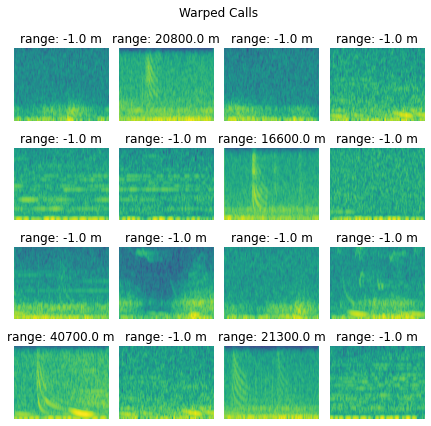

In [5]:
# Make plot
plotter.plot_grid(X_w, y_w[:,0], label_text="range:", sub_titles=True, title="Warped Calls", dim=(4,4), randomize=True)

In [ ]:
dataset = dataLoader.Gunshot(dir_path=test_data, max_range=max_range, transform=dataLoader.get_image_transforms()['eval'], squeeze=True, hpf=False)
dataloader = data.DataLoader(dataset, batch_size=16, drop_last=False, shuffle=False, num_workers=28)

In [ ]:
a = next(iter(dataloader))
i = a[0]
r = a[1]

In [ ]:
plotter.plot_grid(i.numpy(), r.numpy().squeeze(), label_text="", title="Warped Data", dim=(4,4), randomize=False)